***

# **The Burnout Algorithm**

# *Predicting Who AI is Breaking Before They Break*

***

**Author:** Madlene Oloo

**Dataset:** AI Student Impact Dataset (50,000 students)

**Date:** July 11, 2026

## Problem Definition

Artificial Intelligence is no longer a future consideration for higher education but the present reality. `First defined by John McCarthy in 1955 as "the science and engineering of making intelligent machines,"` AI has evolved from a narrow technical discipline into a general-purpose infrastructure embedded in how students research, write, think, and submit work. Large language models in particular have compressed that evolution dramatically: a student today can generate a research paper, debug code, or draft an essay in minutes.

  `Institutions have responded largely by measuring adoption.`
      How many students use AI tools? 
      How often? 
      Which platforms? 
      What policies govern their use?

  `What institutions have not measured, at least not systematically, is what this adoption is doing to students on the inside.`

This gap is not incidental. It reflects a broader failure in how AI integration in education has been theorized and implemented. `Sasikala and Ravichandran (2024) note that AI's potential to reshape the educational landscape is increasingly apparent, yet the frameworks for understanding its human cost remain underdeveloped.` Scholars have examined challenges in AI integration (Hwang et al., 2020), ethical risks including academic dishonesty and surveillance (Qadir, 2023; Williamson, 2017), and the tension between AI automation and the empathy and nuanced understanding that human educators provide (Holmes & Tuomi, 2022). What remains underexplored, as Selwyn (2022) observes, is the long-term impact of AI on student wellbeing and educational equity.

The concern this project addresses sits precisely in that gap.

Students are being handed access to powerful AI tools without structured training in how to use them. The result, this project hypothesizes, is not uniform benefit but stratified risk. Students who understand how to engage AI actively, as a thinking partner rather than an answer machine, may thrive. `Students who use it passively, at high volumes, without the prompt literacy to direct it meaningfully, may be accumulating a hidden cognitive and emotional cost: burnout.`

**Burnout in this context is not merely exhaustion.** It is the erosion of the sense of competence, agency, and purpose that sustains academic engagement. When AI use hollows out the learning process, when students produce outputs they did not meaningfully construct; the result is a kind of productivity that feels real but builds nothing. And when the real test arrives, there is nothing underneath.

This project uses a dataset of 50,000 students to ask a specific, answerable question:

  > Can we predict which students are at highest risk of AI-induced burnout; based on how much they use AI, how skillfully they use it, and how their institutions support or restrict that use; before the semester ends?

The answer has implications that extend beyond the classroom. `The students burning out today are the professionals entering organizations tomorrow. Any institution: university, employer, NGO, or government; investing in AI adoption without investing in AI literacy is not building capability. It is building a delayed crisis.`

This project builds the early warning system to find it first.

***

## Loading Libararies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

***

## Loading Dataset

In [3]:
# Load the dataset

asid = pd.read_csv(r'C:\Users\User\Desktop\ML-1-Final-Capstone-Project\DATA\ai_student_impact_dataset.csv')

In [4]:
asid.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [5]:
asid.shape

(50000, 16)

## Data Cleaning and Preprocessing

In [6]:
# Dataset Information

asid.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

In [7]:
# Check for missing values

asid.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

In [8]:
# Check for duplicates

asid.duplicated().sum()

np.int64(0)

In [9]:
# Separate categorical and numerical columns

categorical_columns = asid.select_dtypes(include=['str']).columns
numerical_columns = asid.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:", categorical_columns)
print("Numerical Columns:", numerical_columns)

Categorical Columns: Index(['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
       'Prompt_Engineering_Skill', 'Institutional_Policy',
       'Burnout_Risk_Level'],
      dtype='str')
Numerical Columns: Index(['Student_ID', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours',
       'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score'],
      dtype='str')


In [10]:
# Remove irrelevant columns

asid.drop(['Student_ID'], axis=1, inplace=True)

In [11]:
asid.shape

(50000, 15)

In [12]:
# Redefine numerical columns after dropping irrelevant columns

numerical_columns = asid.select_dtypes(include=['int64', 'float64']).columns

In [13]:
print(asid[numerical_columns].describe())

       Pre_Semester_GPA  Weekly_GenAI_Hours  Tool_Diversity  \
count      50000.000000        50000.000000     50000.00000   
mean           3.146102            8.427752         2.80026   
std            0.478854            8.269490         1.18802   
min            1.183000            0.000000         1.00000   
25%            2.834000            2.390000         2.00000   
50%            3.210000            5.800000         3.00000   
75%            3.521000           11.720000         4.00000   
max            3.998000           40.000000         5.00000   

       Traditional_Study_Hours  Perceived_AI_Dependency  \
count             50000.000000             50000.000000   
mean                 11.209271                 3.505360   
std                   5.156426                 1.820812   
min                   1.000000                 1.000000   
25%                   7.560000                 2.000000   
50%                  11.180000                 3.000000   
75%                

In [14]:
# Check unique values in categorical columns

asid[categorical_columns].nunique()

for col in categorical_columns:
    print(f"Value counts for {col}:")
    print(asid[col].value_counts())
    print("\n")

Value counts for Major_Category:
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64


Value counts for Year_of_Study:
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64


Value counts for Primary_Use_Case:
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64


Value counts for Prompt_Engineering_Skill:
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64


Value counts for Institutional_Policy:
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64


Value counts for Burnout_Risk_Level:
Burnout_Risk_Level
M

In [15]:
# Convert Paid Subscription to integer

asid['Paid_Subscription'] = asid['Paid_Subscription'].astype(int)

print(asid['Paid_Subscription'].unique())

[1 0]


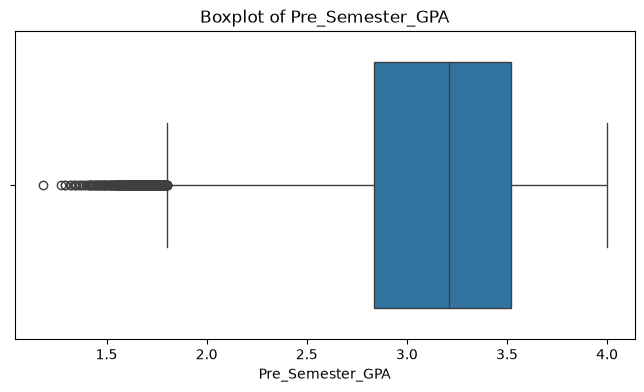

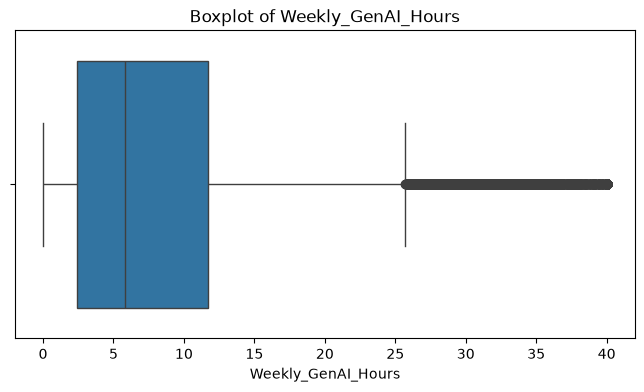

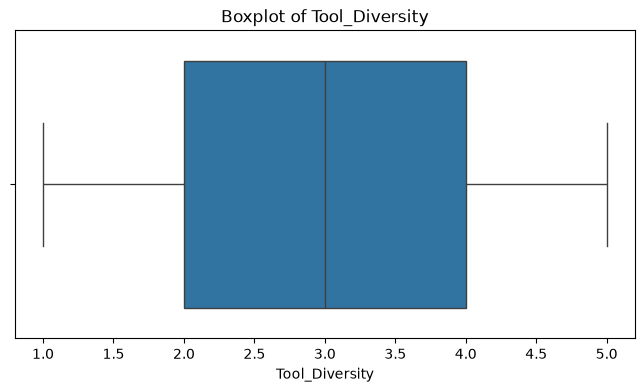

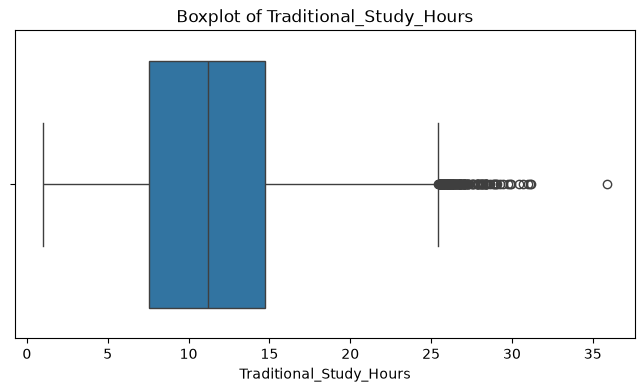

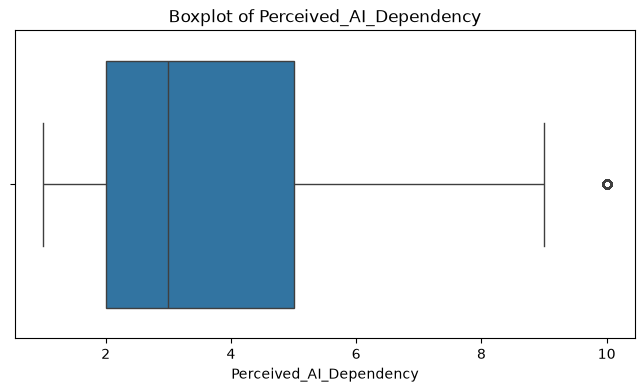

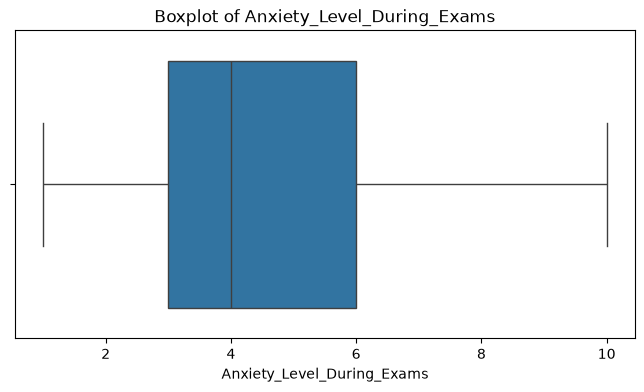

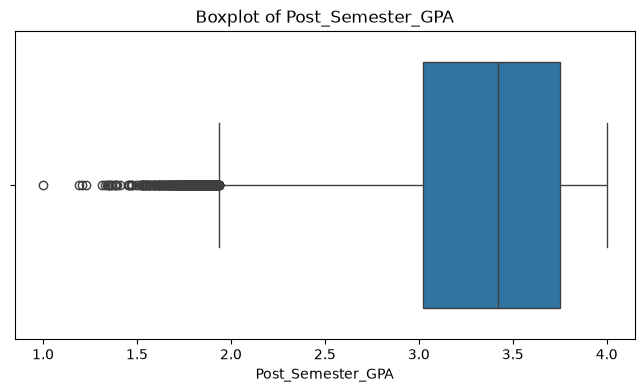

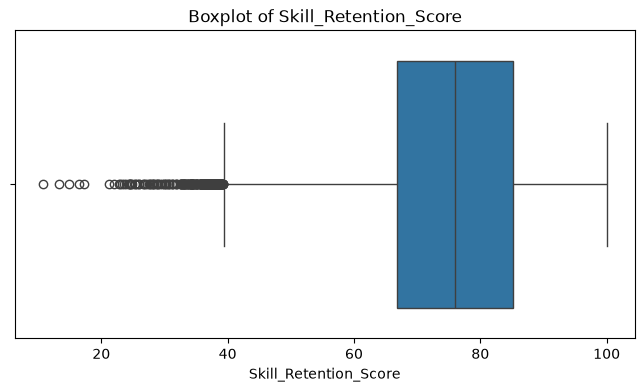

In [16]:
# Check outliers in numerical columns using boxplots

for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=asid[col])
    plt.title(f'Boxplot of {col}')
    plt.show()  

In [17]:
# Investigate Extreme Outliers in Numerical Columns

print(asid['Weekly_GenAI_Hours'].nlargest(10).values)

print(asid['Skill_Retention_Score'].nsmallest(10).values)

[40. 40. 40. 40. 40. 40. 40. 40. 40. 40.]
[10.78 13.23 14.88 16.54 17.22 21.25 21.97 22.76 22.92 23.31]


In [18]:
# Calculate outlier boundaries using mean ± 2 std

for col in ['Weekly_GenAI_Hours', 'Traditional_Study_Hours', 
            'Skill_Retention_Score', 'Pre_Semester_GPA']:
    mean = asid[col].mean()
    std = asid[col].std()
    lower = mean - 2 * std
    upper = mean + 2 * std
    outliers = asid[(asid[col] < lower) | (asid[col] > upper)].shape[0]
    
    print(f"{col}:")
    print(f"  Lower bound: {lower:.2f} | Upper bound: {upper:.2f}")
    print(f"  Outliers outside bounds: {outliers}")
    print()

Weekly_GenAI_Hours:
  Lower bound: -8.11 | Upper bound: 24.97
  Outliers outside bounds: 2832

Traditional_Study_Hours:
  Lower bound: 0.90 | Upper bound: 21.52
  Outliers outside bounds: 1210

Skill_Retention_Score:
  Lower bound: 49.23 | Upper bound: 102.36
  Outliers outside bounds: 1308

Pre_Semester_GPA:
  Lower bound: 2.19 | Upper bound: 4.10
  Outliers outside bounds: 1884



### Decision Log

- After calculating mean ± 2 standard deviation boundaries, I identified outliers in four numerical columns. 

    - **Weekly_GenAI_Hours**: Maximum value is exactly 40.0 across all top records; indicating a data collection ceiling, not erroneous entries. 
  Retain as is.

    - **Skill_Retention_Score**: Low values (10–23%) represent students with poor knowledge retention; central to the project's research question. 
  Retain as is.

    - **Traditional_Study_Hours**: High values plausible for graduate students during intensive study periods. 
  Retain as is.
  
    - **Pre_Semester_GPA**: Low entry GPAs are valid and relevant to burnout prediction. 
  Retain as is.

In [19]:
# Final check — confirm clean dataset

print(f"Final dataset shape: {asid.shape}")
print(f"Missing values: {asid.isnull().sum().sum()}")
print(f"Duplicates: {asid.duplicated().sum()}")
print()
print("Data types:")
print(asid.dtypes)

Final dataset shape: (50000, 15)
Missing values: 0
Duplicates: 0

Data types:
Major_Category                    str
Year_of_Study                     str
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case                  str
Prompt_Engineering_Skill          str
Tool_Diversity                  int64
Paid_Subscription               int64
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy              str
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level                str
dtype: object


***

## Exploratory Data Analysis (EDA)

### Univariate Analysis

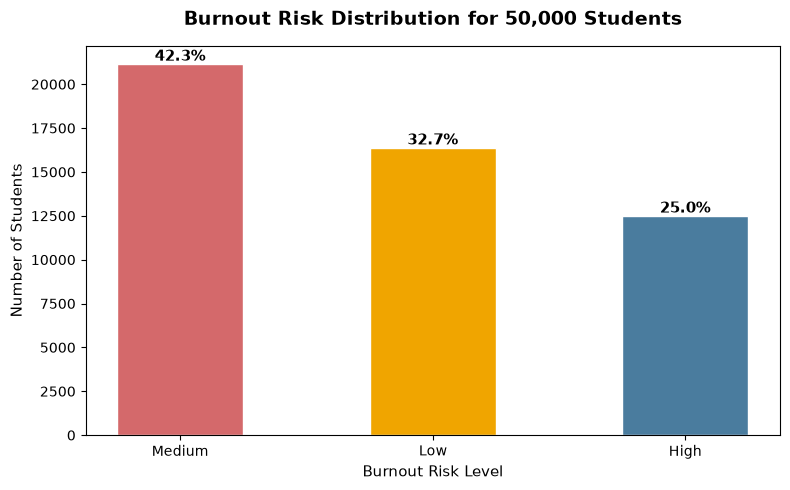

In [20]:
# Target Variable Distribution
# Burnout_Score Distribution

# How is burnout distributed across the 50,000 students?

burnout_counts = asid['Burnout_Risk_Level'].value_counts()
burnout_pct = asid['Burnout_Risk_Level'].value_counts(normalize=True).mul(100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#d4696b', '#f0a500', '#4a7c9e']
bars = ax.bar(burnout_counts.index, burnout_counts.values, 
              color=colors, edgecolor='white', width=0.5)

ax.set_title('Burnout Risk Distribution for 50,000 Students', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Burnout Risk Level', fontsize=11)
ax.set_ylabel('Number of Students', fontsize=11)

for bar, pct in zip(bars, burnout_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{pct}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\ML-1-Final-Capstone-Project\OUTPUT', dpi=150, bbox_inches='tight')
plt.show()

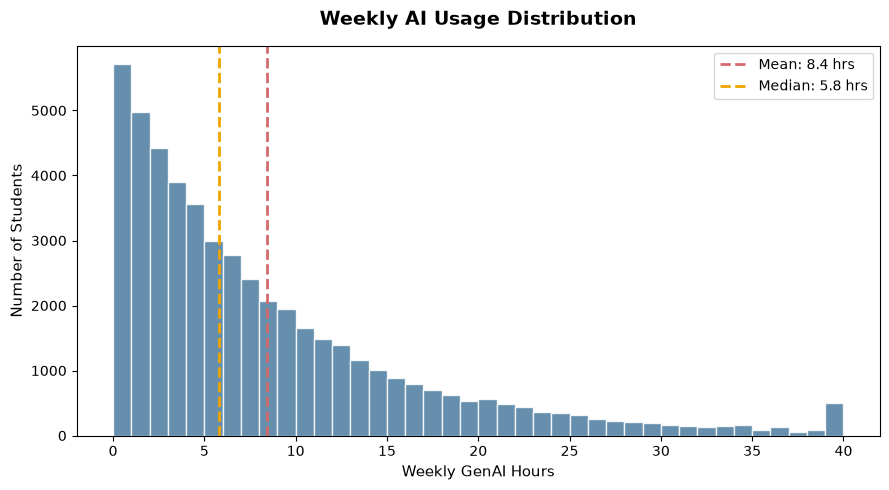

In [21]:
# How much AI are students actually using?

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(asid['Weekly_GenAI_Hours'], bins=40, 
        color='#4a7c9e', edgecolor='white', alpha=0.85)

ax.set_title('Weekly AI Usage Distribution', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Weekly GenAI Hours', fontsize=11)
ax.set_ylabel('Number of Students', fontsize=11)

ax.axvline(asid['Weekly_GenAI_Hours'].mean(), color='#d4696b', 
           linewidth=2, linestyle='--', label=f"Mean: {asid['Weekly_GenAI_Hours'].mean():.1f} hrs")
ax.axvline(asid['Weekly_GenAI_Hours'].median(), color='#f0a500', 
           linewidth=2, linestyle='--', label=f"Median: {asid['Weekly_GenAI_Hours'].median():.1f} hrs")

ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\ML-1-Final-Capstone-Project\OUTPUT\eda_ai_usage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

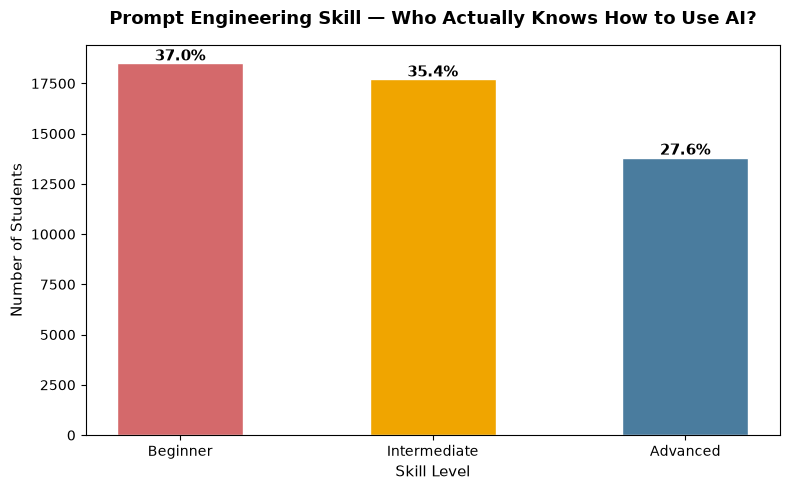

In [ ]:
# Who actually knows how to use AI well?

skill_counts = asid['Prompt_Engineering_Skill'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#d4696b', '#f0a500', '#4a7c9e']
bars = ax.bar(skill_counts.index, skill_counts.values,
              color=colors, edgecolor='white', width=0.5)

ax.set_title('Prompt Engineering Skill — Who Actually Knows How to Use AI?',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Skill Level', fontsize=11)
ax.set_ylabel('Number of Students', fontsize=11)

for bar in bars:
    pct = bar.get_height() / len(asid) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\ML-1-Final-Capstone-Project\OUTPUT\eda_prompt_skill_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Findings Log

- **25% of students are at high burnout risk** with 42.3% in the 
  medium zone, the majority are not thriving.

- **Median AI usage is just 5.8 hours/week** but a significant tail of heavy users stretches to the 40-hour ceiling.

- **Only 27.6% of students are advanced prompt users**, more than a third are beginners using tools they don't fully understand.

### Bivariate Analysis

C:\Users\User\AppData\Local\Temp\ipykernel_10716\3288342846.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=asid, x='Burnout_Risk_Level', y='Weekly_GenAI_Hours',


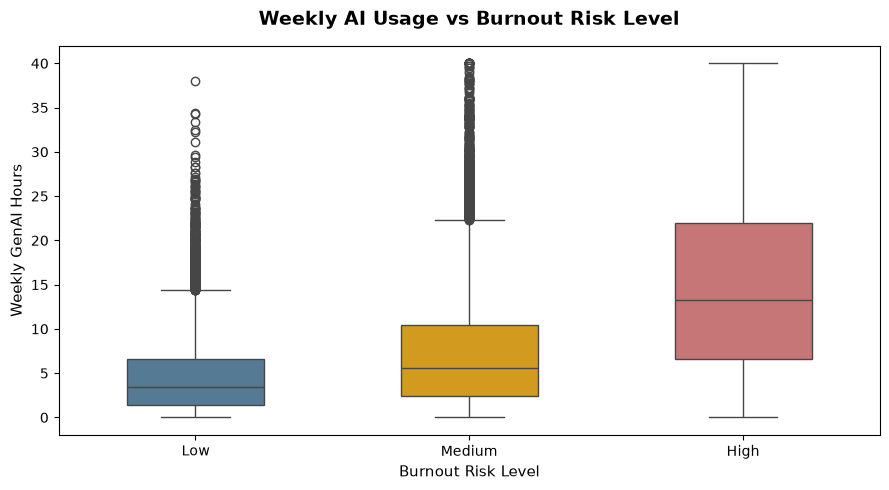

In [ ]:
# Does using more AI lead to higher burnout?
# AI Usage vs Burnout Risk Level

fig, ax = plt.subplots(figsize=(9, 5))

order = ['Low', 'Medium', 'High']
colors = ['#4a7c9e', '#f0a500', '#d4696b']

sns.boxplot(data=asid, x='Burnout_Risk_Level', y='Weekly_GenAI_Hours',
            order=order, palette=colors, ax=ax, width=0.5)

ax.set_title('Weekly AI Usage vs Burnout Risk Level',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Burnout Risk Level', fontsize=11)
ax.set_ylabel('Weekly GenAI Hours', fontsize=11)

plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\ML-1-Final-Capstone-Project\OUTPUT\eda_usage_vs_burnout.png', dpi=150, bbox_inches='tight')
plt.show()

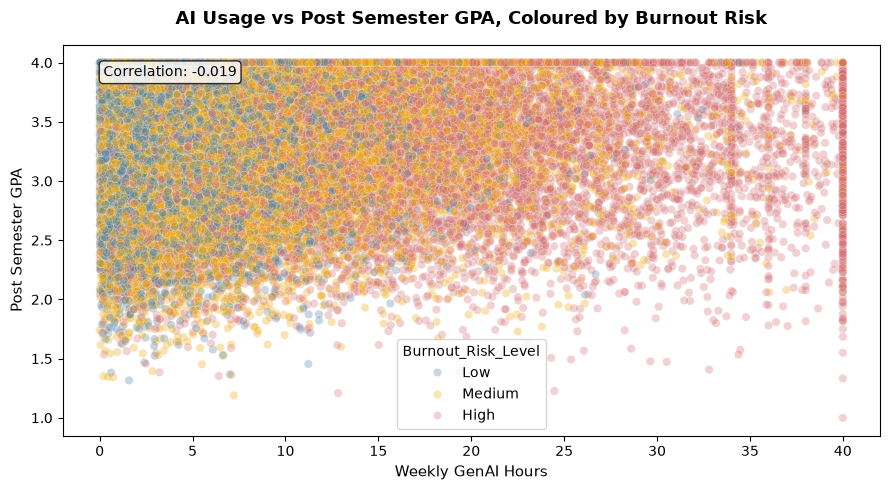

In [25]:
# Does more AI usage improve grades?
# Weekly AI Usage vs Post Semester GPA

fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(data=asid, x='Weekly_GenAI_Hours', y='Post_Semester_GPA',
                hue='Burnout_Risk_Level', 
                hue_order=['Low', 'Medium', 'High'],
                palette=['#4a7c9e', '#f0a500', '#d4696b'],
                alpha=0.3, ax=ax)

ax.set_title('AI Usage vs Post Semester GPA, Coloured by Burnout Risk',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Weekly GenAI Hours', fontsize=11)
ax.set_ylabel('Post Semester GPA', fontsize=11)

# Add correlation
corr = asid['Weekly_GenAI_Hours'].corr(asid['Post_Semester_GPA'])
ax.text(0.05, 0.92, f'Correlation: {corr:.3f}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\ML-1-Final-Capstone-Project\OUTPUT\eda_usage_vs_gpa.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Average AI hours by burnout level — clean summary

means = asid.groupby('Burnout_Risk_Level')['Weekly_GenAI_Hours'].mean().reindex(order)
print("=== Mean Weekly AI Hours by Burnout Level ===")
print(means.round(2))

print()
# Average GPA by burnout level
gpa_means = asid.groupby('Burnout_Risk_Level')['Post_Semester_GPA'].mean().reindex(order)
print("=== Mean Post Semester GPA by Burnout Level ===")
print(gpa_means.round(3))

=== Mean Weekly AI Hours by Burnout Level ===
Burnout_Risk_Level
Low        4.64
Medium     7.35
High      15.21
Name: Weekly_GenAI_Hours, dtype: float64

=== Mean Post Semester GPA by Burnout Level ===
Burnout_Risk_Level
Low       3.405
Medium    3.348
High      3.278
Name: Post_Semester_GPA, dtype: float64


### Findings Log

**AI usage strongly predicts burnout but not academic performance.**

- High burnout students use AI an average of 15.21 hours per week;  
  more than 3x the 4.64 hours logged by low burnout students.
- The correlation between AI usage and GPA is virtually zero (-0.019), 
  meaning more AI hours produce no meaningful grade improvement.

The tool is extracting a cost from students without delivering 
a proportional academic return.

If hours don't help grades, does skill make a difference? 

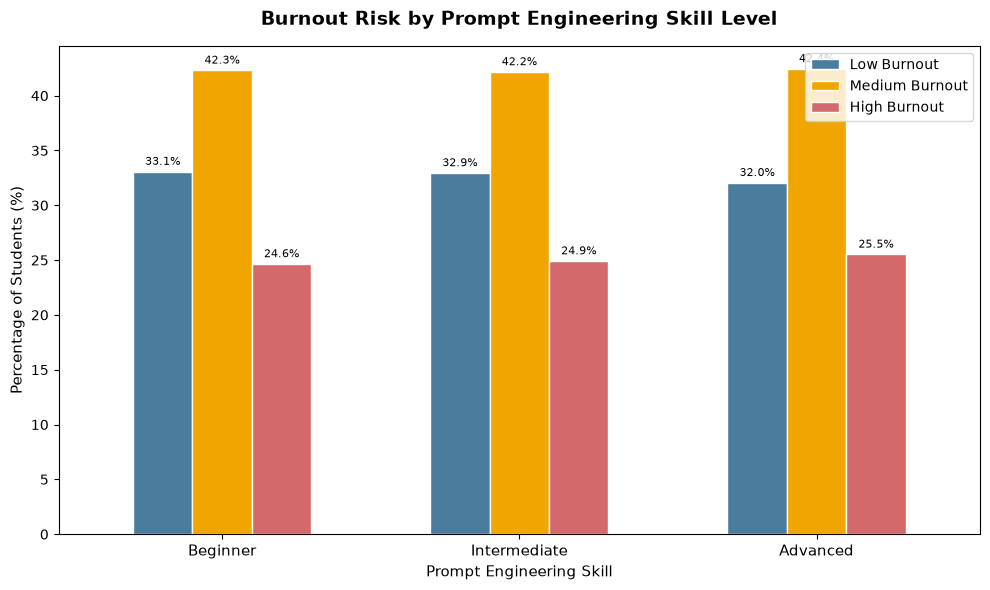

In [16]:
# Does skill level change everything?
# Burnout risk by prompt engineering skill level

skill_burnout = asid.groupby(['Prompt_Engineering_Skill', 'Burnout_Risk_Level']).size().unstack()
skill_burnout_pct = skill_burnout.div(skill_burnout.sum(axis=1), axis=0) * 100

order_skill = ['Beginner', 'Intermediate', 'Advanced']
skill_burnout_pct = skill_burnout_pct.reindex(order_skill)

fig, ax = plt.subplots(figsize=(10, 6))

skill_burnout_pct[['Low', 'Medium', 'High']].plot(
    kind='bar',
    ax=ax,
    color=['#4a7c9e', '#f0a500', '#d4696b'],
    edgecolor='white',
    width=0.6
)

ax.set_title('Burnout Risk by Prompt Engineering Skill Level',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Prompt Engineering Skill', fontsize=11)
ax.set_ylabel('Percentage of Students (%)', fontsize=11)
ax.set_xticklabels(order_skill, rotation=0, fontsize=11)
ax.legend(['Low Burnout', 'Medium Burnout', 'High Burnout'], fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig('C:\\Users\\User\\Desktop\\ML-1-Final-Capstone-Project\\OUTPUT\\eda_skill_vs_burnout.png', dpi=150, bbox_inches='tight')
plt.show()

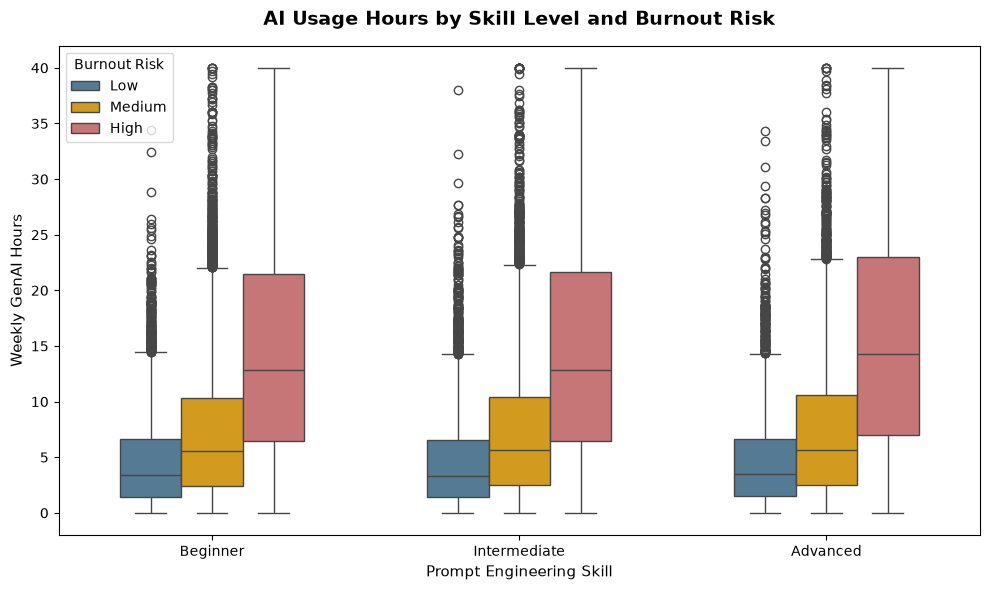

In [17]:
# The dangerous combination of high usage AND beginner skill

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=asid, x='Prompt_Engineering_Skill', y='Weekly_GenAI_Hours',
            hue='Burnout_Risk_Level',
            hue_order=['Low', 'Medium', 'High'],
            order=order_skill,
            palette=['#4a7c9e', '#f0a500', '#d4696b'],
            ax=ax, width=0.6)

ax.set_title('AI Usage Hours by Skill Level and Burnout Risk',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Prompt Engineering Skill', fontsize=11)
ax.set_ylabel('Weekly GenAI Hours', fontsize=11)
ax.legend(title='Burnout Risk', fontsize=10)

plt.tight_layout()
plt.savefig('C:\\Users\\User\\Desktop\\ML-1-Final-Capstone-Project\\OUTPUT\\eda_skill_usage_burnout.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Exact numbers of high burnout percentage by skill level

print("=== % of Students at HIGH Burnout Risk by Skill Level ===")
for skill in order_skill:
    subset = asid[asid['Prompt_Engineering_Skill'] == skill]
    high_pct = (subset['Burnout_Risk_Level'] == 'High').sum() / len(subset) * 100
    print(f"{skill}: {high_pct:.1f}%")

print()
print("=== Mean AI Hours for HIGH burnout students by Skill Level ===")
high_burnout = asid[asid['Burnout_Risk_Level'] == 'High']
print(high_burnout.groupby('Prompt_Engineering_Skill')['Weekly_GenAI_Hours'].mean().round(2))

=== % of Students at HIGH Burnout Risk by Skill Level ===
Beginner: 24.6%
Intermediate: 24.9%
Advanced: 25.5%

=== Mean AI Hours for HIGH burnout students by Skill Level ===
Prompt_Engineering_Skill
Advanced        15.89
Beginner        14.93
Intermediate    14.97
Name: Weekly_GenAI_Hours, dtype: float64


### Finding Log

**Prompt engineering skill alone does not protect students from burnout.**

High burnout rates are nearly identical across all skill levels:  
24.6% for Beginners, 24.9% for Intermediate, and 25.5% for Advanced users. Skill gives students the capacity to use AI more effectively, but advanced users who burn out are using AI at even higher volumes (mean 15.89 hrs) than beginner burnout cases (mean 14.93 hrs).

The implication is significant: skill without disciplined usage 
patterns is not a safeguard. Advanced users can burn out just as 
readily; they simply require more hours of unsupported use to 
get there.

If it's not about how much you use AI, and not simply about how skilled you are, is it about what you're actually doing with it?

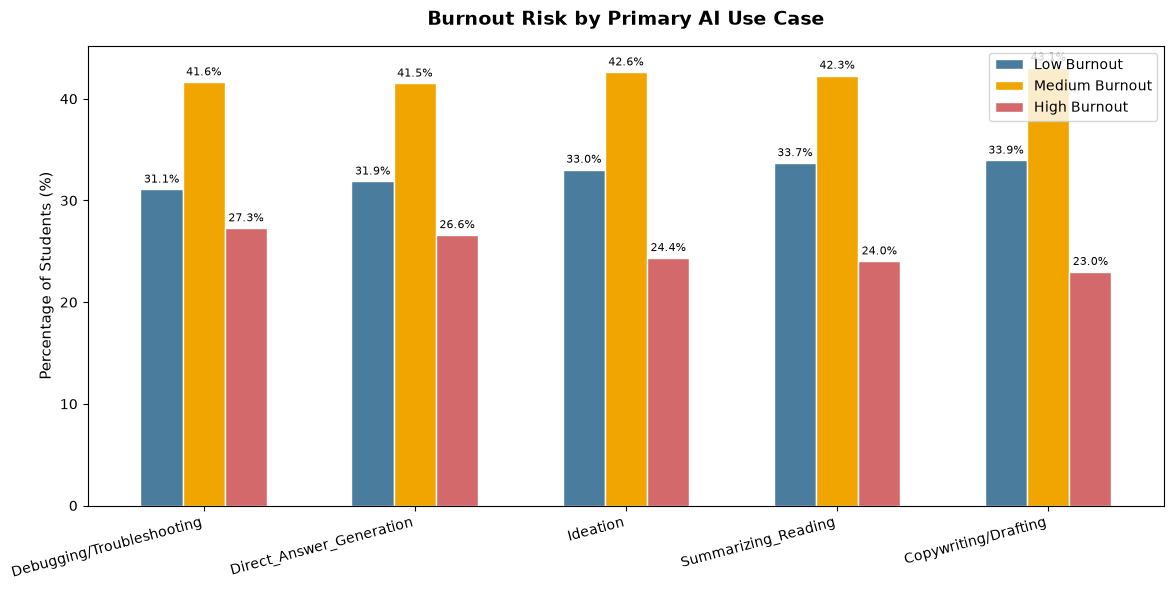

In [20]:
# Does what you use AI FOR predict burnout?

use_burnout = asid.groupby(['Primary_Use_Case', 'Burnout_Risk_Level']).size().unstack()
use_burnout_pct = use_burnout.div(use_burnout.sum(axis=1), axis=0) * 100

# Sort by High burnout percentage
use_burnout_pct = use_burnout_pct.sort_values('High', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

use_burnout_pct[['Low', 'Medium', 'High']].plot(
    kind='bar',
    ax=ax,
    color=['#4a7c9e', '#f0a500', '#d4696b'],
    edgecolor='white',
    width=0.6
)

ax.set_title('Burnout Risk by Primary AI Use Case',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Percentage of Students (%)', fontsize=11)
ax.set_xticklabels(use_burnout_pct.index, rotation=15, 
                   ha='right', fontsize=10)
ax.legend(['Low Burnout', 'Medium Burnout', 'High Burnout'], fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig('C:\\Users\\User\\Desktop\\ML-1-Final-Capstone-Project\\OUTPUT\\eda_usecase_vs_burnout.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_16380\3459568137.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(use_burnout_pct.index, rotation=15,


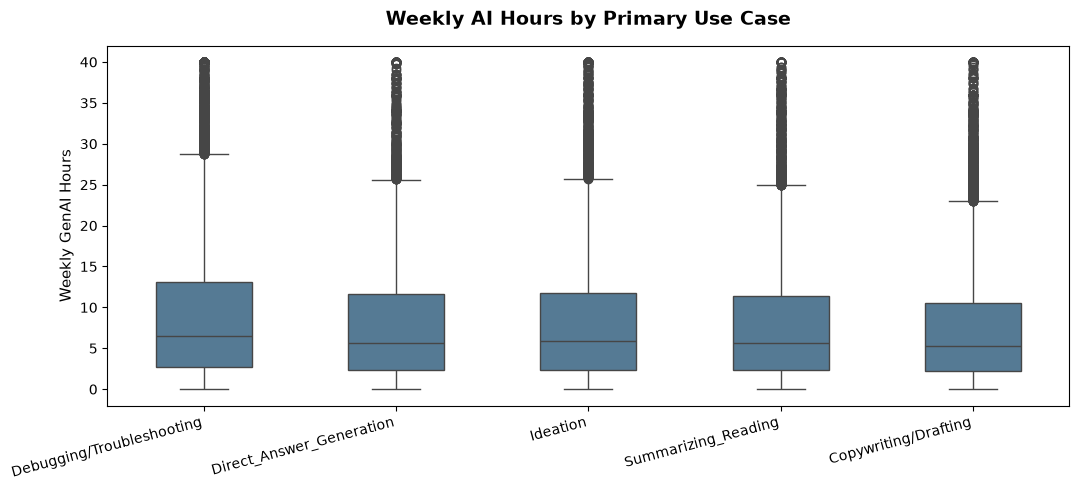

In [22]:
# Do certain use cases drive more hours?

fig, ax = plt.subplots(figsize=(11, 5))

sns.boxplot(data=asid, x='Primary_Use_Case', y='Weekly_GenAI_Hours',
            order=use_burnout_pct.index,
            color='#4a7c9e', ax=ax, width=0.5)

ax.set_title('Weekly AI Hours by Primary Use Case',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Weekly GenAI Hours', fontsize=11)
ax.set_xticklabels(use_burnout_pct.index, rotation=15, 
                   ha='right', fontsize=10)

plt.tight_layout()
plt.savefig('C:\\Users\\User\\Desktop\\ML-1-Final-Capstone-Project\\OUTPUT\\eda_usecase_hours.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# High burnout % by use case ranked

print("=== % at HIGH Burnout Risk by Primary Use Case ===")
for use in use_burnout_pct.index:
    subset = asid[asid['Primary_Use_Case'] == use]
    high_pct = (subset['Burnout_Risk_Level'] == 'High').sum() / len(subset) * 100
    mean_hrs = subset['Weekly_GenAI_Hours'].mean()
    print(f"{use}: {high_pct:.1f}% high burnout | Mean hrs: {mean_hrs:.1f}")

=== % at HIGH Burnout Risk by Primary Use Case ===
Debugging/Troubleshooting: 27.3% high burnout | Mean hrs: 9.4
Direct_Answer_Generation: 26.6% high burnout | Mean hrs: 8.5
Ideation: 24.4% high burnout | Mean hrs: 8.4
Summarizing_Reading: 24.0% high burnout | Mean hrs: 8.2
Copywriting/Drafting: 23.0% high burnout | Mean hrs: 7.6


### Findings Log

**The type of AI use predicts burnout — but not in the way expected.**

Debugging/Troubleshooting carries the highest burnout rate at 27.3%, followed by Direct Answer Generation at 26.6%. Copywriting/Drafting has the lowest at 23.0%.

Crucially, hour distributions are nearly identical across all use 
cases; the difference in burnout is not explained by time spent. 
It is explained by cognitive load.

Students using AI for debugging are engaging in high-intensity 
problem-solving for an average of 9.4 hours per week. The AI 
assists but the cognitive demand remains high. Students using 
AI for copywriting and drafting experience lower strain, likely 
because the collaboration feels generative rather than grinding.

The implication: burnout is not simply about how much you use AI 
or even how skillfully. It is about the cognitive cost of what 
you are asking yourself and the AI to do.

Can we build a model that sees all of this at once and predicts who burns out before they do? 

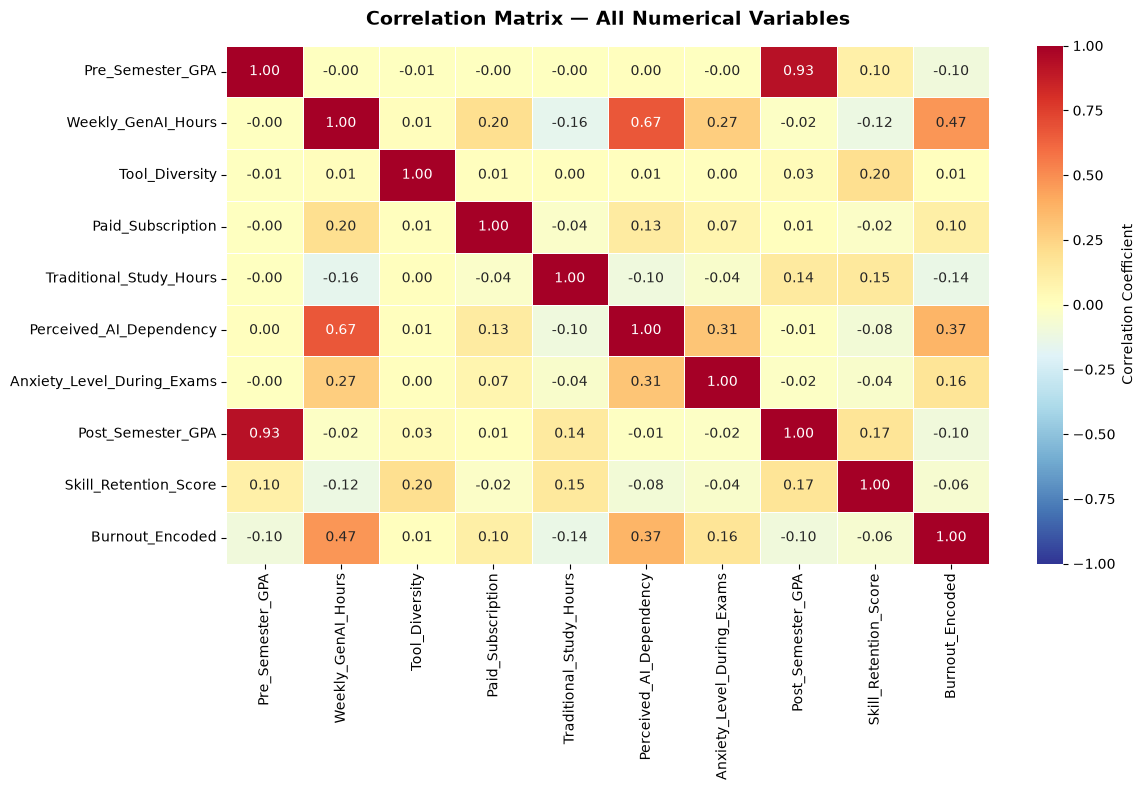

In [24]:
# Correlation heatmap for all numerical variables

fig, ax = plt.subplots(figsize=(12, 8))

# Encode target temporarily for correlation
df_corr = asid.copy()
df_corr['Burnout_Encoded'] = df_corr['Burnout_Risk_Level'].map(
    {'Low': 0, 'Medium': 1, 'High': 2})

num_cols = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity',
            'Paid_Subscription', 'Traditional_Study_Hours', 
            'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams',
            'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Encoded']

corr_matrix = df_corr[num_cols].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='RdYlBu_r',
            ax=ax,
            linewidths=0.5,
            vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlation Coefficient'})

ax.set_title('Correlation Matrix — All Numerical Variables',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('C:\\Users\\User\\Desktop\\ML-1-Final-Capstone-Project\\OUTPUT\\eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Findings Log

**Variables most strongly correlated with burnout risk:**

- `Weekly_GenAI_Hours` (0.47) — the primary driver
- `Perceived_AI_Dependency` (0.37) — psychological cost of heavy use
- `Anxiety_Level_During_Exams` (0.16) — emotional toll
- `Traditional_Study_Hours` (-0.14) — protective factor

**Key additional finding:**
Weekly AI hours and perceived dependency correlate at 0.67;  students using AI the most are also developing the strongest 
psychological dependency on it. This is not just a productivity 
pattern. It is a behavioral relationship with implications beyond 
academic performance.

**Feature selection for modelling:**
Weekly_GenAI_Hours, Perceived_AI_Dependency, 
Anxiety_Level_During_Exams, Traditional_Study_Hours, 
Paid_Subscription, and all categorical variables will be 
prioritized as model inputs.

***

## Feature Engineering and Selection

In [22]:
# The key engineered feature:
# High usage + low skill = highest burnout risk
# We capture this as a ratio

# First encode skill level numerically
skill_map = {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}
asid['Skill_Encoded'] = asid['Prompt_Engineering_Skill'].map(skill_map)

# Create usage intensity score
# Higher score = more hours per unit of skill = higher risk
asid['Usage_Intensity_Score'] = asid['Weekly_GenAI_Hours'] / asid['Skill_Encoded']

print("Usage Intensity Score created ✓")
print()
print(asid['Usage_Intensity_Score'].describe().round(2))

Usage Intensity Score created ✓

count    50000.00
mean         5.35
std          6.17
min          0.00
25%          1.30
50%          3.26
75%          7.06
max         40.00
Name: Usage_Intensity_Score, dtype: float64


In [23]:
# Does Usage_Intensity_Score predict burnout better than hours alone?
print("=== Mean Usage Intensity Score by Burnout Level ===")
print(asid.groupby('Burnout_Risk_Level')['Usage_Intensity_Score']
      .mean().reindex(['Low', 'Medium', 'High']).round(2))

print()
print("=== Compare: Mean Weekly Hours by Burnout Level ===")
print(asid.groupby('Burnout_Risk_Level')['Weekly_GenAI_Hours']
      .mean().reindex(['Low', 'Medium', 'High']).round(2))

print()
# Correlation with burnout
asid['Burnout_Encoded'] = asid['Burnout_Risk_Level'].map(
    {'Low': 0, 'Medium': 1, 'High': 2})

corr_hours = asid['Weekly_GenAI_Hours'].corr(asid['Burnout_Encoded'])
corr_intensity = asid['Usage_Intensity_Score'].corr(asid['Burnout_Encoded'])

print(f"Correlation — Weekly Hours vs Burnout: {corr_hours:.3f}")
print(f"Correlation — Usage Intensity vs Burnout: {corr_intensity:.3f}")
print()
print("Does the engineered feature outperform raw hours?", 
      "YES ✓" if corr_intensity > corr_hours else "NO — investigate")

=== Mean Usage Intensity Score by Burnout Level ===
Burnout_Risk_Level
Low       2.97
Medium    4.68
High      9.58
Name: Usage_Intensity_Score, dtype: float64

=== Compare: Mean Weekly Hours by Burnout Level ===
Burnout_Risk_Level
Low        4.64
Medium     7.35
High      15.21
Name: Weekly_GenAI_Hours, dtype: float64

Correlation — Weekly Hours vs Burnout: 0.469
Correlation — Usage Intensity vs Burnout: 0.394

Does the engineered feature outperform raw hours? NO — investigate


In [28]:
# ENCODING — prepare all categorical variables

asid_model = asid.copy()

# 1. Ordinal encoding — variables with natural order
skill_map = {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}
year_map = {'Freshman': 1, 'Sophomore': 2, 'Junior': 3, 
            'Senior': 4, 'Graduate': 5}
policy_map = {'Strict_Ban': 1, 'Allowed_With_Citation': 2, 
              'Actively_Encouraged': 3}

asid_model['Prompt_Engineering_Skill'] = asid_model['Prompt_Engineering_Skill'].map(skill_map)
asid_model['Year_of_Study'] = asid_model['Year_of_Study'].map(year_map)
asid_model['Institutional_Policy'] = asid_model['Institutional_Policy'].map(policy_map)

print("Ordinal encoding done")
print(asid_model[['Prompt_Engineering_Skill', 
                'Year_of_Study', 
                'Institutional_Policy']].head())

Ordinal encoding done
   Prompt_Engineering_Skill  Year_of_Study  Institutional_Policy
0                         1              4                     2
1                         3              3                     2
2                         1              1                     1
3                         2              4                     2
4                         3              2                     2


In [29]:
# 2. One-Hot Encoding — nominal variables (no natural order)

asid_model = pd.get_dummies(asid_model, 
                           columns=['Major_Category', 'Primary_Use_Case'],
                           drop_first=True)

print("One-Hot Encoding done")
print(f"Columns after encoding: {asid_model.shape[1]}")
print(asid_model.columns.tolist())

One-Hot Encoding done
Columns after encoding: 24
['Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level', 'Skill_Encoded', 'Usage_Intensity_Score', 'Burnout_Encoded', 'Major_Category_Business', 'Major_Category_Humanities', 'Major_Category_Medical', 'Major_Category_STEM', 'Primary_Use_Case_Debugging/Troubleshooting', 'Primary_Use_Case_Direct_Answer_Generation', 'Primary_Use_Case_Ideation', 'Primary_Use_Case_Summarizing_Reading']


In [30]:
# 3. Encode target variable

target_map = {'Low': 0, 'Medium': 1, 'High': 2}
asid_model['Burnout_Risk_Level'] = asid_model['Burnout_Risk_Level'].map(target_map)

print("Target encoded")
print(asid_model['Burnout_Risk_Level'].value_counts())

Target encoded
Burnout_Risk_Level
1    21144
0    16369
2    12487
Name: count, dtype: int64


In [31]:
# Drop columns not needed for modelling

cols_to_drop = [
    'Burnout_Encoded',  # duplicate of target
    'Skill_Encoded',    # already captured in Prompt_Engineering_Skill
    'Post_Semester_GPA',  # outcome variable — would leak into model
    'Skill_Retention_Score'  # outcome variable — would leak into model
]

df_model = asid_model.drop(columns=cols_to_drop)

# Define X and y
X = asid_model.drop(columns=['Burnout_Risk_Level'])
y = asid_model['Burnout_Risk_Level']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print()
print("Features used:")
print(X.columns.tolist())

Features shape: (50000, 23)
Target shape: (50000,)

Features used:
['Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Skill_Encoded', 'Usage_Intensity_Score', 'Burnout_Encoded', 'Major_Category_Business', 'Major_Category_Humanities', 'Major_Category_Medical', 'Major_Category_STEM', 'Primary_Use_Case_Debugging/Troubleshooting', 'Primary_Use_Case_Direct_Answer_Generation', 'Primary_Use_Case_Ideation', 'Primary_Use_Case_Summarizing_Reading']


In [32]:
# StandardScaler — mean 0, variance 1
# Only scale numerical columns — encoded categoricals stay as is

numerical_features = [
    'Weekly_GenAI_Hours', 'Pre_Semester_GPA', 
    'Traditional_Study_Hours', 'Perceived_AI_Dependency',
    'Anxiety_Level_During_Exams', 'Tool_Diversity',
    'Usage_Intensity_Score', 'Paid_Subscription',
    'Year_of_Study', 'Prompt_Engineering_Skill',
    'Institutional_Policy'
]

scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

print("Scaling complete ✓")
print()
print(X[numerical_features].describe().round(2))

Scaling complete ✓

       Weekly_GenAI_Hours  Pre_Semester_GPA  Traditional_Study_Hours  \
count            50000.00          50000.00                 50000.00   
mean                -0.00             -0.00                    -0.00   
std                  1.00              1.00                     1.00   
min                 -1.02             -4.10                    -1.98   
25%                 -0.73             -0.65                    -0.71   
50%                 -0.32              0.13                    -0.01   
75%                  0.40              0.78                     0.68   
max                  3.82              1.78                     4.78   

       Perceived_AI_Dependency  Anxiety_Level_During_Exams  Tool_Diversity  \
count                 50000.00                    50000.00        50000.00   
mean                     -0.00                       -0.00           -0.00   
std                       1.00                        1.00            1.00   
min                

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")
print()
print("Target distribution in training set:")
print(y_train.value_counts().sort_index())
print()
print("Target distribution in test set:")
print(y_test.value_counts().sort_index())

Training set: 40000 rows
Testing set: 10000 rows

Target distribution in training set:
Burnout_Risk_Level
0    13095
1    16915
2     9990
Name: count, dtype: int64

Target distribution in test set:
Burnout_Risk_Level
0    3274
1    4229
2    2497
Name: count, dtype: int64


***

## Model Selection

The main multiclass algorithmic families:

- Tree-Based Ensembles: Random Forest - Yes

- Gradient Boosted Trees: XGBoost, LightGBM, CatBoost - Yes

- Linear and Logistic Models: Logistic Regression, Linear SVM - No

- Distance-Based Models: k-Nearest-kNN 

- Naive Bayes: GaussianNB, MultinomialNB

In [39]:
# Reload clean unscaled features

asid_model = asid.copy()

# Apply all encoding again on fresh copy

skill_map = {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}
year_map = {'Freshman': 1, 'Sophomore': 2, 'Junior': 3, 
            'Senior': 4, 'Graduate': 5}
policy_map = {'Strict_Ban': 1, 'Allowed_With_Citation': 2, 
              'Actively_Encouraged': 3}

asid_model['Prompt_Engineering_Skill'] = asid_model['Prompt_Engineering_Skill'].map(skill_map)
asid_model['Year_of_Study'] = asid_model['Year_of_Study'].map(year_map)
asid_model['Institutional_Policy'] = asid_model['Institutional_Policy'].map(policy_map)

# Usage intensity score

asid_model['Usage_Intensity_Score'] = (asid_model['Weekly_GenAI_Hours'] / 
                                      asid_model['Prompt_Engineering_Skill'])

# One-hot encoding

asid_model = pd.get_dummies(asid_model, 
                           columns=['Major_Category', 'Primary_Use_Case'],
                           drop_first=True)

# Encode target

target_map = {'Low': 0, 'Medium': 1, 'High': 2}
asid_model['Burnout_Risk_Level'] = asid_model['Burnout_Risk_Level'].map(target_map)

# Drop leakage columns

cols_to_drop = ['Post_Semester_GPA', 'Skill_Retention_Score', 
                'Burnout_Encoded', 'Skill_Encoded']

# Drop only if they exist

cols_to_drop = [c for c in cols_to_drop if c in asid_model.columns]
asid_model = asid_model.drop(columns=cols_to_drop)

# Define X and y — UNSCALED this time

X = asid_model.drop(columns=['Burnout_Risk_Level'])
y = asid_model['Burnout_Risk_Level']

# Train test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features: {X.shape[1]} columns")
print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

Features: 19 columns
Training set: 40000 rows
Testing set: 10000 rows


### Findings Log

An accuracy of 51% on am multiclass problem means the linear model is struggling to capture the complex, non-linear relationships in the dataset.

Moving on to a powerful tree-based model: Random Forest

***

## Model Training

In [38]:
# Define pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])

# Train
pipeline.fit(X_train, y_train)

print("Pipeline trained ✓")
print()

# Predict
y_pred = pipeline.predict(X_test)

# Accuracy
accuracy = pipeline.score(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.1f}%")

Pipeline trained ✓

Model Accuracy: 51.3%


***

## Model Evaluation and Tuning

***

## Model Deployment

***

## References

Baker, T., Smith, L., & Anissa, N. (2019). Educ-AI-tion rebooted? Exploring the future of artificial intelligence in schools and colleges. Available online: https://www.nesta.org.uk/report/education-rebooted/ (accessed on 29 January 2025).

Facione, P. A. (2020). Critical thinking: What it is and why it counts. Insight Assessment. Available online: https://insightassessment.com/unlock-resources/ (accessed on 29 January 2025).

Holmes, W., & Tuomi, I. (2022). State of the art and practice in AI in education. European Journal of Education, 57, 542–570. [Google Scholar] [CrossRef]

Hwang, G. J., Xie, H., Wah, B. W., & Gasevic, D. (2020). Vision, challenges, roles, and research issues of artificial intelligence in education. Computers & Education: Artificial Intelligence, 1, 100001. [Google Scholar] [CrossRef]

Luckin, R., Holmes, W., Griffiths, M., & Forcier, L. B. (2016). Intelligence unleashed: An argument for AI in education. Pearson Education. [Google Scholar]

Sasikala, P., & Ravichandran, R. (2024). Study on the Impact of Artificial Intelligence on Student Learning Outcomes. Journal of Digital Learning and Education, 4(2), 145–155. https://doi.org/10.52562/jdle.v4i2.1234

Selwyn, N. (2022). Should robots replace teachers? AI and the future of education. Polity Press. [Google Scholar]

(2019). Stanford.Edu. https://hai.stanford.edu/ai-definitions/what-is-artificial-intelligence-ai

Vieriu, A. M., & Petrea, G. (2025). The Impact of Artificial Intelligence (AI) on Students’ Academic Development. Education Sciences, 15(3), 343. https://doi.org/10.3390/educsci15030343






